# Get a relationship for da/dlwp vs LWP (albedo susceptbility) from Ci's paper (Song et al, 2024, GRL)

In [1]:
import pickle

import numpy as np
import matplotlib.pyplot as plt

from scipy import stats


In [2]:
# numbers taken from Fig 2a, Song et al. (2024), GRL
lwp = [46.68524919166017, 31.394804326011823, 24.192217638532725, 67.25610435946037, 86.17683130783811, 108.68324227896088, 127.08663173151969, 153.86330694614784, 18.358791392574425, 16.601627829189432, 13.426245958300814, 176.19355558033226, 206.8012041476196, 243.9357787936225, 294.87568290779353, 346.6518006466719, 10.600958858289665, 8.141375850150519]
dadlwp = [2.677754064237346, 3.352651964271599, 4.155181408584301, 2.238716307011303, 1.913292756830817, 1.609854293468237, 1.488936315969752, 1.3982662767106684, 4.8499249071219666, 5.481295286275129, 6.364830184702131, 1.3202118409611887, 1.247395462809264, 1.1653571522672779, 1.0297578584038152, 0.9141517139620056, 7.374963770979895, 8.314125365583747]

# convert to (kg/m2)
lwp = [x/1000. for x in lwp]


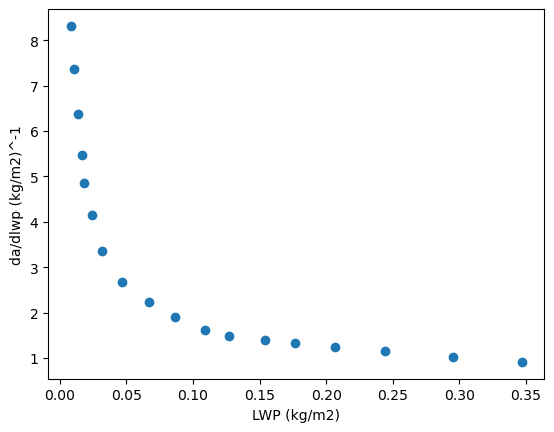

In [3]:
plt.scatter(lwp, dadlwp)
plt.ylabel("da/dlwp (kg/m2)^-1")
plt.xlabel("LWP (kg/m2)")
plt.show()


In [4]:
x_inv = [1/n for n in lwp]
result = stats.linregress(x_inv, y=dadlwp)


In [5]:
m = result.slope
b = result.intercept
def dadlwp_from_lwp(lwp_inv):
    return m*lwp_inv + b

In [6]:
print(m, b)

0.06562158843739113 1.0760460556166351


In [7]:
# Ci Song's analysis - check the fit looks good with the CMIP6 models

cmip6_lwp_path = "/glade/u/home/cisong/test_codes/codes_figures/slopes/global_lwp_dlwp_15north_dadlwp0dot12/"
cmip6_dict = {}
cmip6_plot_order = [
    "HadGEM3-GC31-LL",
    "MIROC6",
    "IPSL-CM6A-LR",
    "CNRM-CM6-1",
    "CESM2",
    "GFDL-CM4",
    "CNRM-ESM2-1",
    "CanESM5"
]
for model in cmip6_plot_order:
    data = dict(np.load(cmip6_lwp_path + "cmip6-{}.npz".format(model)))
    cmip6_dict[model] = data
    

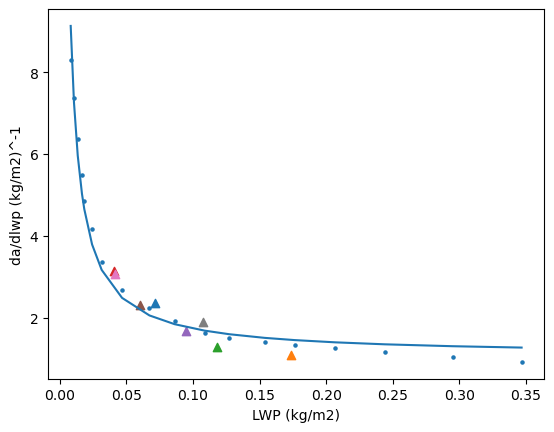

In [8]:
xsorted = np.array(list(sorted(lwp)))

plt.scatter(lwp, dadlwp, s=5)
plt.plot(xsorted, dadlwp_from_lwp(1/xsorted))
col_list = ["C{}".format(x) for x in np.arange(0, 10)]
for i, model in enumerate(cmip6_plot_order):
    plt.scatter(cmip6_dict[model]["lwp"], cmip6_dict[model]["dadlwp"], marker="^", color=col_list[i])

plt.ylabel("da/dlwp (kg/m2)^-1")
plt.xlabel("LWP (kg/m2)")
plt.show()

In [9]:
with open("/glade/u/home/jnug/work/multi_PPE_data/pickle_jar/lwp_inv__da_dlwp__fit.pickle", "wb") as handle:
    pickle.dump({"m": result.slope, "b": result.intercept}, handle)
    

In [10]:
# also from Ci's paper - the obs constraint there
y = [1.7, 2.1]
